In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


In [5]:
# Load Dataset
df = pd.read_csv("heart.csv")

In [7]:
# Features and Target
X = df.drop("target", axis=1)
y = df["target"]

In [9]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 820
Testing Samples: 205


In [13]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.9853658536585366


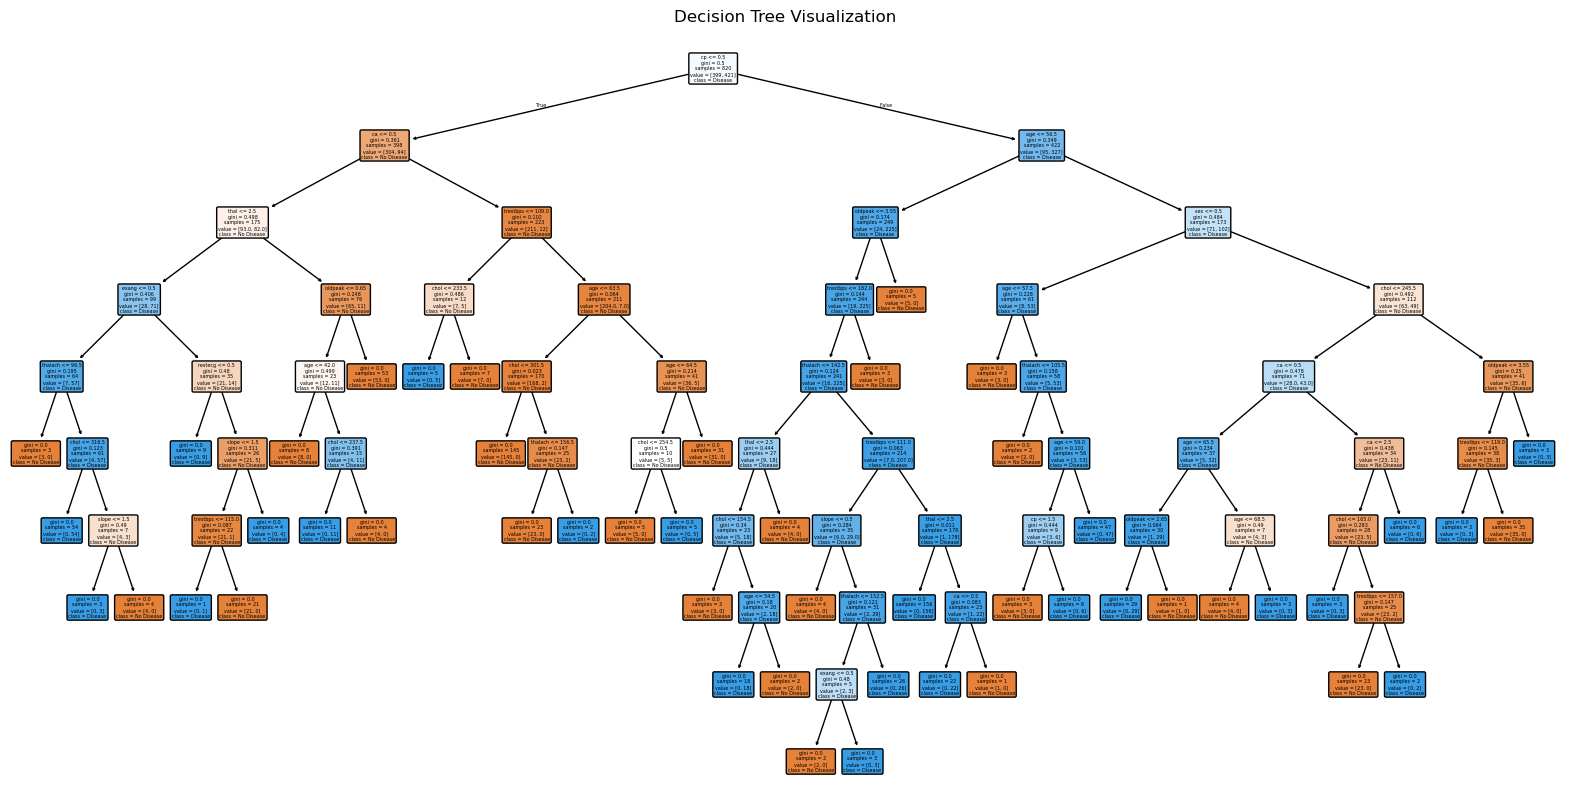

In [15]:
plt.figure(figsize=(20,10))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=["No Disease", "Disease"],
    filled=True,
    rounded=True
)

plt.title("Decision Tree Visualization")
plt.show()

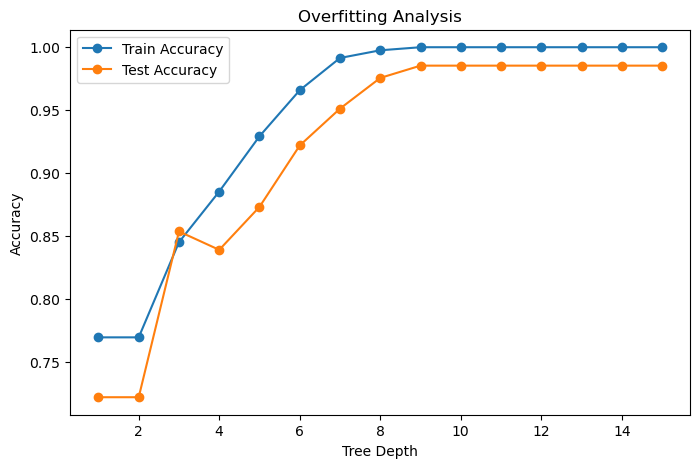

In [17]:
train_acc = []
test_acc = []

depths = range(1, 16)

for depth in depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_acc.append(
        model.score(X_train, y_train)
    )

    test_acc.append(
        model.score(X_test, y_test)
    )

plt.figure(figsize=(8,5))

plt.plot(depths, train_acc, marker='o', label='Train Accuracy')
plt.plot(depths, test_acc, marker='o', label='Test Accuracy')

plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Overfitting Analysis")
plt.legend()

plt.show()

In [19]:
dt_pruned = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

dt_pruned.fit(X_train, y_train)

y_pred_pruned = dt_pruned.predict(X_test)

print(
    "Pruned Tree Accuracy:",
    accuracy_score(y_test, y_pred_pruned)
)

Pruned Tree Accuracy: 0.8390243902439024


In [21]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 1.0


In [23]:
print("\nModel Comparison")
print("---------------------")
print("Decision Tree :", dt_accuracy)
print("Random Forest :", rf_accuracy)


Model Comparison
---------------------
Decision Tree : 0.9853658536585366
Random Forest : 1.0


In [25]:
importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

     Feature  Importance
2         cp    0.142094
7    thalach    0.117349
11        ca    0.114844
9    oldpeak    0.112634
12      thal    0.095930
0        age    0.091285
4       chol    0.077771
8      exang    0.073707
3   trestbps    0.067765
10     slope    0.048711
1        sex    0.026682
6    restecg    0.020438
5        fbs    0.010790


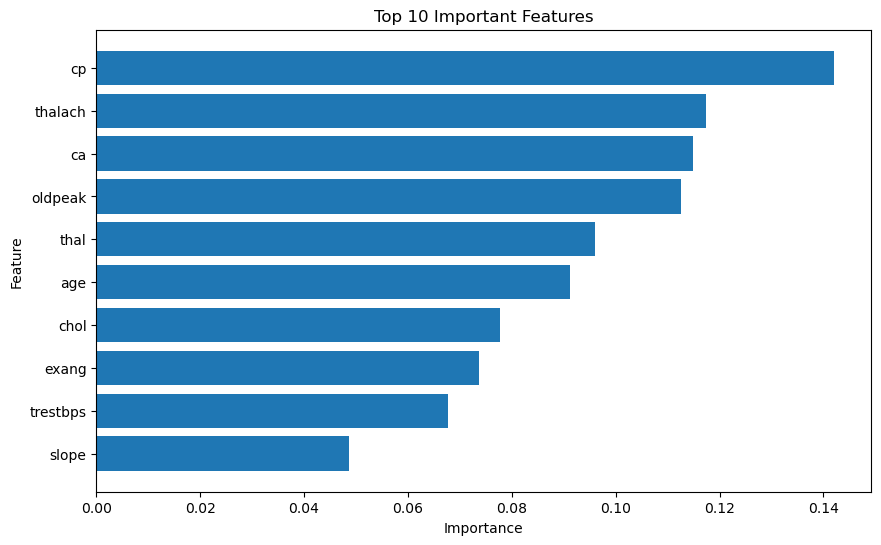

In [27]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()

In [29]:
cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5
)

print("Cross Validation Scores:")
print(cv_scores)

print(
    "Average CV Accuracy:",
    cv_scores.mean()
)

Cross Validation Scores:
[1.         1.         1.         1.         0.98536585]
Average CV Accuracy: 0.9970731707317073


In [31]:
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



In [33]:
cm = confusion_matrix(
    y_test,
    y_pred_rf
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[100   0]
 [  0 105]]
